<a href="https://colab.research.google.com/github/Anggardy/Item-Demand-Forecasting-Project/blob/main/itemDemand_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.callbacks import EarlyStopping

# Penguncian Keacakan

In [ ]:
# Mengunci keacakan di level library dasar Python
import random
random.seed(42)

# Mengunci keacakan di level library manipulasi angka (Numpy)
import numpy as np
np.random.seed(42)

# Mengunci keacakan di level otak Deep Learning-nya (TensorFlow)
import tensorflow as tf
tf.random.set_seed(42)

# Akses Dataset

In [ ]:
import kagglehub
path = kagglehub.dataset_download("dhrubangtalukdar/store-item-demand-forecasting-dataset")

Using Colab cache for faster access to the 'store-item-demand-forecasting-dataset' dataset.


In [ ]:
import pandas as pd

df = pd.read_csv('/kaggle/input/store-item-demand-forecasting-dataset/retail_sales.csv')

# Explorasi Data

In [ ]:
df.head()

,date,store_id,item_id,sales,price,promo,weekday,month
0,2019-01-01,store_1,item_1,41,21.30,0,1,1
1,2019-01-02,store_1,item_1,53,21.30,0,2,1
2,2019-01-03,store_1,item_1,39,21.30,0,3,1
3,2019-01-04,store_1,item_1,35,21.30,0,4,1
4,2019-01-05,store_1,item_1,51,17.04,1,5,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4565000 entries, 0 to 4564999
Data columns (total 8 columns):
 #   Column    Dtype  
---  ------    -----  
 0   date      object 
 1   store_id  object 
 2   item_id   object 
 3   sales     int64  
 4   price     float64
 5   promo     int64  
 6   weekday   int64  
 7   month     int64  
dtypes: float64(1), int64(4), object(3)
memory usage: 278.6+ MB


## Menyiapkan Data

## Mengubah tipe data tanggal

In [ ]:
df['date'] = pd.to_datetime(df['date'])

In [ ]:
# Membuat jumlah sales tiap date
df_agg = df.groupby('date')['sales'].sum().reset_index()

# Ekstraksi fitur
df_agg['tahun'] = df_agg['date'].dt.year
df_agg['bulan'] = df_agg['date'].dt.month
df_agg['hari'] = df_agg['date'].dt.day
df_agg['hari_dalam_minggu'] = df_agg['date'].dt.dayofweek

In [ ]:
df_agg.head()

,date,sales,tahun,bulan,hari,hari_dalam_minggu
0,2019-01-01,74119,2019,1,1,1
1,2019-01-02,77119,2019,1,2,2
2,2019-01-03,70810,2019,1,3,3
3,2019-01-04,59269,2019,1,4,4
4,2019-01-05,52621,2019,1,5,5


## Mengambil data sales (penjualan)

In [ ]:
data_sales = df_agg['sales'].values.reshape(-1, 1)
print(data_sales)

[[74119]
 [77119]
 [70810]
 ...
 [74957]
 [66218]
 [70053]]


## Normalisasi

In [ ]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_sales = scaler.fit_transform(data_sales).flatten()

## Sliding Window

In [ ]:
def create_sequences(data, timesteps):
  X_seq, y_seq = [], []
  for i in range(len(data) - timesteps):
    X_seq.append(data[i : i + timesteps])
    y_seq.append(data[i + timesteps])

  return np.array(X_seq), np.array(y_seq)

In [ ]:
timestep = 7
X_all, y_all = create_sequences(scaled_sales, timestep)

X_all = X_all.reshape((X_all.shape[0], X_all.shape[1], 1))

print(f"Bentuk data X setelah Sliding Window: {X_all.shape}")

Bentuk data X setelah Sliding Window: (1819, 7, 1)


## Data Split

In [ ]:
# Train menggunakan data selain 1 tahun terakhir
X_train_seq = X_all[:-365]
y_train_seq = y_all[:-365]

# Test menggunakan data 1 tahun terakhir
X_test_seq = X_all[-365:]
y_test_seq = y_all[-365:]

## Model

In [ ]:
modelLSTM = Sequential([
    LSTM(50, activation='relu',input_shape=(timestep, 1)),
    Dense(1)
])

modelLSTM.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

## Compile

In [ ]:
# Compile Model
modelLSTM.compile(optimizer='adam', loss='mse', metrics=['mean_absolute_percentage_error'])

# Penggunaan Callback untuk menghentikan model sebelum overfitting
CALLBACK = EarlyStopping(
    monitor='val_mean_absolute_percentage_error',
    patience=15,
    restore_best_weights=True,
    mode='min'
)

history = modelLSTM.fit(
    X_train_seq, y_train_seq,
    epochs=60, batch_size=32,
    validation_data=(X_test_seq, y_test_seq),
    # callbacks=[CALLBACK],
    verbose=1
)

Epoch 1/60
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0579 - mean_absolute_percentage_error: 136708.4375 - val_loss: 0.0212 - val_mean_absolute_percentage_error: 33.7381
Epoch 2/60
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0159 - mean_absolute_percentage_error: 136398.4531 - val_loss: 0.0176 - val_mean_absolute_percentage_error: 31.5776
Epoch 3/60
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0128 - mean_absolute_percentage_error: 102083.8516 - val_loss: 0.0145 - val_mean_absolute_percentage_error: 27.1084
Epoch 4/60
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0088 - mean_absolute_percentage_error: 77929.9375 - val_loss: 0.0077 - val_mean_absolute_percentage_error: 18.2397
Epoch 5/60
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0043 - mean_absolute_percentage_error: 91437.9219 - val_loss: 0.0034 - val_mean_absolute_percentage_error: 11.4687
Epoch 6/60
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0022 - mean_absolute_percentage_error: 91444.5078 - val_

## Hasil pelatihan

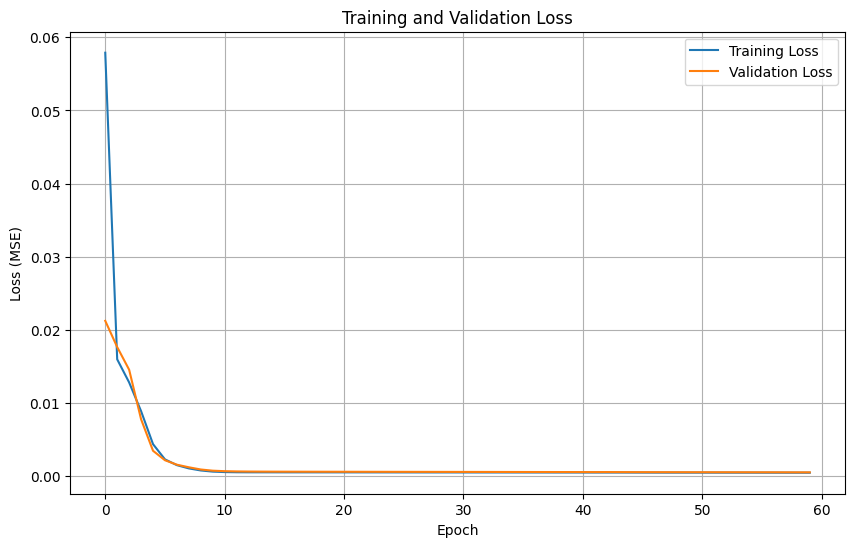

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

# Prediksi

In [ ]:
predictionLSTM = modelLSTM.predict(X_test_seq)
predictionLSTM_original = scaler.inverse_transform(predictionLSTM).flatten()

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


In [ ]:
aktual_60_hari = scaler.inverse_transform(y_test_seq[-60:].reshape(-1, 1)).flatten()
prediksi_60_hari = predictionLSTM_original[-60:]

In [ ]:
mapeLSTM = mean_absolute_percentage_error(aktual_60_hari, prediksi_60_hari) * 100
print(f'MAPE LSTM: {mapeLSTM:.2f}%')

MAPE LSTM: 2.03%


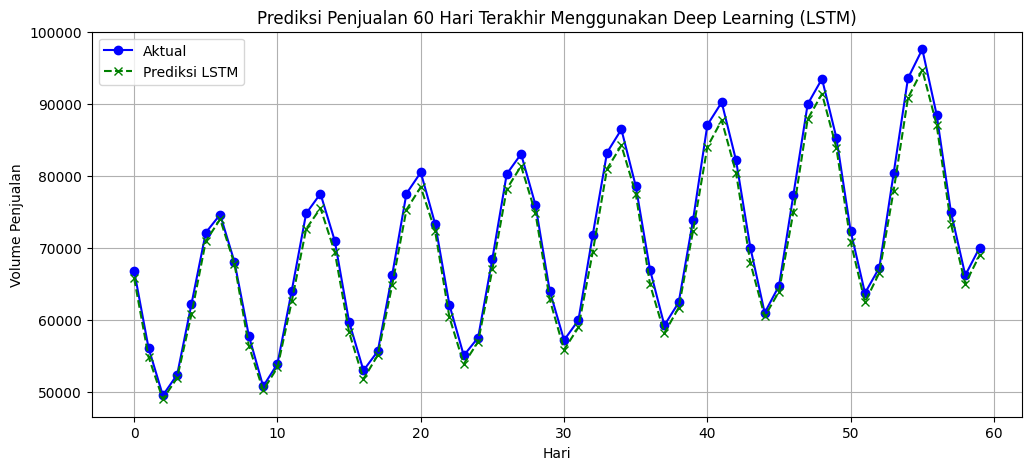

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(aktual_60_hari, label='Aktual', marker='o', color='blue')
plt.plot(prediksi_60_hari, label='Prediksi LSTM', marker='x', linestyle='--', color='green')
plt.title('Prediksi Penjualan 60 Hari Terakhir Menggunakan Deep Learning (LSTM)')
plt.ylabel('Volume Penjualan')
plt.xlabel('Hari')
plt.legend()
plt.grid(True)
plt.show()